<a href="https://colab.research.google.com/github/Nouramua/Data-Science-Project/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Linear_SVM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Arabic Readability Classification On BAREC Corpus Using Linear SVM Model**


This notebook presents the implementation of a Linear Support Vector Machine (Linear SVM) for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: 19-level and 5-level.

A baseline model is first established using the default hyperparameters, followed by hyperparameter tuning using GridSearchCV to identify the optimal regularization parameter.

Finally, the tuned model is evaluated with and without class balancing, and the performance of all models is compared using multiple evaluation metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [ ]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [ ]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [ ]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [ ]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [ ]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [ ]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [ ]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [ ]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [ ]:
# Distribution for Readability Level 19
level_19_stats = (
    filtered_full_df["Readability_Level_19"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_19_stats["Percentage"] = (
    level_19_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 19 ===")
display(level_19_stats)


# Distribution for Readability Level 5
level_5_stats = (
    filtered_full_df["Readability_Level_5"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_5_stats["Percentage"] = (
    level_5_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 5 ===")
display(level_5_stats)

=== Readability Level 19 ===


,Count,Percentage
Readability_Level_19,,
1,409,0.59
2,437,0.63
3,1462,2.11
4,751,1.08
5,3443,4.96
6,1534,2.21
7,5438,7.83
8,5683,8.18
9,2023,2.91


=== Readability Level 5 ===


,Count,Percentage
Readability_Level_5,,
1,13474,19.40
2,22383,32.23
3,18510,26.66
4,13234,19.06
5,1840,2.65


In [ ]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [ ]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


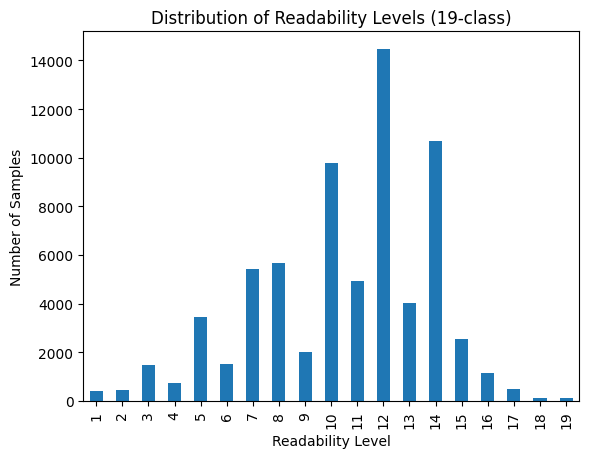

In [ ]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

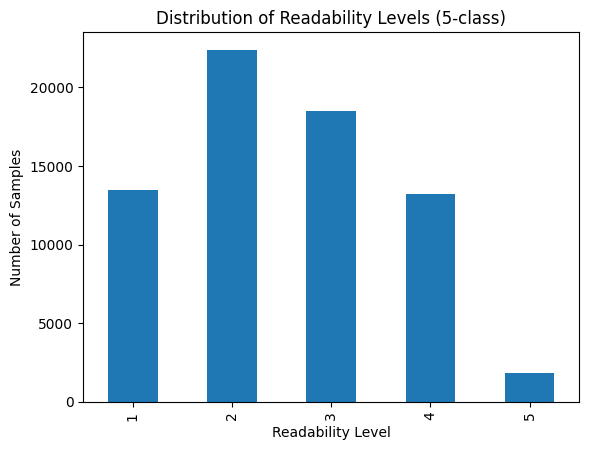

In [ ]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

##**Support Vector Machine (SVM) Model**

**Why SVM?**

Support Vector Machine (SVM) is a powerful supervised learning algorithm widely used for text classification tasks. It is particularly effective for high-dimensional and sparse feature spaces, such as those produced by TF-IDF representations of text. SVM works by finding an optimal hyperplane that separates classes with maximum margin, which helps improve generalization and reduce overfitting. In addition, Linear SVM models are computationally efficient and scale well to large datasets, making them suitable for large-scale Arabic readability classification with multiple classes.

##**SVM Feature Extraction using TF-IDF**

The input text was converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation.

In [ ]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text and target labels
svm_X_train = filtered_train_df["Word"]
svm_X_dev = filtered_dev_df["Word"]
svm_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
svm_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF on the training set and transform all data splits
svm_X_train_tfidf = svm_vectorizer.fit_transform(svm_X_train)
svm_X_dev_tfidf = svm_vectorizer.transform(svm_X_dev)
svm_X_test_tfidf = svm_vectorizer.transform(svm_X_test)

**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_svm_model(y_true, y_pred, dataset_name):
    """
    Evaluate a Linear SVM model using multiple classification metrics.
    """

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print results
    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

**How to call the function?**

evaluate_temp_model(
    temp_y_test,
    temp_baseline_19_test_pred,
    "Baseline Temp (19-Level) - Test Set"
)

##**Confusion Matrix Function**

In [ ]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

plot_confusion_matrix(
    temp_y_test,
    temp_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Temp(19-Level)"
)

---

##**SVM Baseline Model (19-Level)**

In [ ]:
# Define target labels for the 19-level classification task

svm_y_train_19 = filtered_train_df["Readability_Level_19"]
svm_y_dev_19 = filtered_dev_df["Readability_Level_19"]
svm_y_test_19 = filtered_test_df["Readability_Level_19"]

In [ ]:
# Import Linear Support Vector Classifier
from sklearn.svm import LinearSVC

# Create the baseline Linear SVM model using default hyperparameters
svm_baseline_19 = LinearSVC(
    random_state=42
)

print(svm_baseline_19.get_params())

{'C': 1.0, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


In [ ]:
# Train the baseline model
svm_baseline_19.fit(
    svm_X_train_tfidf,
    svm_y_train_19
)

LinearSVC(random_state=42)

In [ ]:
# Generate predictions using the baseline SVM model
svm_baseline_19_test_pred = svm_baseline_19.predict(svm_X_test_tfidf)

In [ ]:
evaluate_svm_model(
    svm_y_test_19,
    svm_baseline_19_test_pred,
    "Baseline SVM (19-Level) - Test Set"
)

Baseline SVM (19-Level) - Test Set
Accuracy:                      0.3833
Adjacent Accuracy (±1):        0.5102
Quadratic Weighted Kappa:      0.5492
Macro F1-score:                0.2769
Weighted Precision:            0.3704
Weighted Recall:               0.3833
Mean Absolute Error (MAE):     1.9484
Root Mean Squared Error:       2.9909
R² Score:                      0.1583

Classification Report:

              precision    recall  f1-score   support

           1       0.40      0.53      0.45        32
           2       0.35      0.19      0.25        36
           3       0.42      0.40      0.41       141
           4       0.34      0.26      0.29        86
           5       0.51      0.45      0.48       380
           6       0.42      0.23      0.30       139
           7       0.47      0.44      0.45       585
           8       0.33      0.38      0.35       541
           9       0.45      0.39      0.42       190
          10       0.43      0.49      0.46      1010
   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

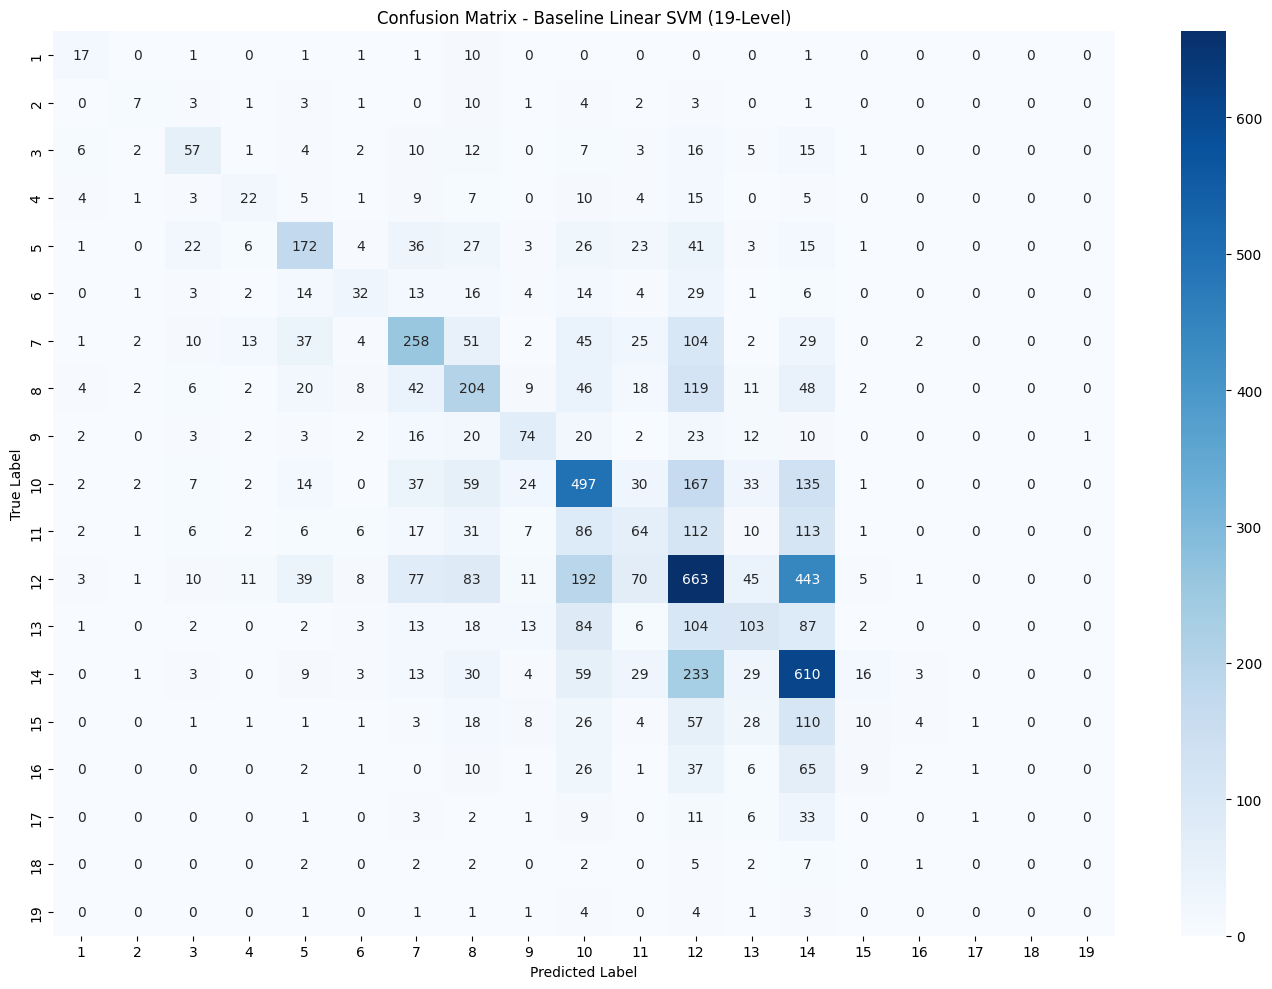

In [ ]:
plot_confusion_matrix(
    svm_y_test_19,
    svm_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Linear SVM (19-Level)"
)

###**SVM Baseline Findings (19-Level)**
..

##**SVM Hyperparameter Tuning Using GridSearchCV (19-Level)**


**Hyperparameter Search Space Justification**

The hyperparameter search space was selected based on recommendations from previous SVM and text classification literature rather than arbitrary choices.

The regularization parameter **C** and **loss** function were tuned because they directly influence the learning behavior and classification performance of a Linear Support Vector Machine (LinearSVC).

The search space was defined as follows:

- C = [0.01, 0.1, 1, 10, 100]
- Loss = [hinge, squared_hinge]

For the regularization parameter C, exponentially spaced values were selected to cover multiple orders of magnitude, ranging from strong to weak regularization, while maintaining computational efficiency. This follows the general recommendation of Hsu et al. (2016) to search across exponentially spaced values for SVM hyperparameters [1].

For the loss function, both hinge and squared_hinge were included because they are the two loss functions supported by LinearSVC. The hinge loss represents the standard SVM loss, while squared_hinge uses the squared hinge loss, providing an alternative formulation for penalizing classification errors. Including both allows the GridSearchCV procedure to empirically determine which loss function performs better for the given dataset.

The same search space was used for both the 19-level and 5-level readability classification tasks to ensure a fair comparison between the two experimental settings.

Although the candidate values remained identical, the optimal combination of hyperparameters was selected independently for each task using the predefined development set.

**References**


[1] Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2016). A Practical Guide to Support Vector Classification.

In [ ]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.svm import LinearSVC
from scipy.sparse import vstack
import numpy as np

# Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "loss": ["hinge", "squared_hinge"]
}

# Combine Training and Development features
X_train_dev = vstack([
    svm_X_train_tfidf,
    svm_X_dev_tfidf
])

# Combine Training and Development labels
y_train_dev = np.concatenate([
    svm_y_train_19,
    svm_y_dev_19
])

# Define the fixed split
# -1 = Training set
#  0 = Development set
test_fold = np.concatenate([
    np.full(len(svm_y_train_19), -1),
    np.zeros(len(svm_y_dev_19))
])

predefined_split = PredefinedSplit(test_fold=test_fold)

# Grid Search
svm_grid_19 = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=predefined_split,
    n_jobs=-1,
    verbose=2
)

# Hyperparameter tuning
svm_grid_19.fit(
    X_train_dev,
    y_train_dev
)

print("Best Parameters:", svm_grid_19.best_params_)
print(f"Best Development Accuracy: {svm_grid_19.best_score_:.4f}")

Fitting 1 folds for each of 10 candidates, totalling 10 fits
Best Parameters: {'C': 1, 'loss': 'squared_hinge'}
Best Development Accuracy: 0.4012


##**SVM Tuned Model (19-Level)**
* **class_weight: Balanced**

In [ ]:
# Create tuned Linear SVM using the best C and loss value with balanced class weights

svm_tuned_19_balanced = LinearSVC(
    C=1,
    loss="squared_hinge",
    class_weight="balanced",
    random_state=42
)

# Train the tuned model
svm_tuned_19_balanced.fit(
    svm_X_train_tfidf,
    svm_y_train_19
)

# Generate predictions
svm_tuned_19_balanced_test_pred = svm_tuned_19_balanced.predict(svm_X_test_tfidf)

In [ ]:
evaluate_svm_model(
    svm_y_test_19,
    svm_tuned_19_balanced_test_pred,
    "Tuned Linear SVM (19-Level) - Balanced"
)

Tuned Linear SVM (19-Level) - Balanced
Accuracy:                      0.3671
Adjacent Accuracy (±1):        0.5045
Quadratic Weighted Kappa:      0.5308
Macro F1-score:                0.2686
Weighted Precision:            0.3720
Weighted Recall:               0.3671
Mean Absolute Error (MAE):     2.1264
Root Mean Squared Error:       3.2855
R² Score:                      -0.0157

Classification Report:

              precision    recall  f1-score   support

           1       0.19      0.53      0.28        32
           2       0.11      0.19      0.14        36
           3       0.29      0.45      0.35       141
           4       0.19      0.30      0.23        86
           5       0.42      0.47      0.44       380
           6       0.33      0.35      0.34       139
           7       0.43      0.47      0.45       585
           8       0.31      0.39      0.34       541
           9       0.35      0.40      0.37       190
          10       0.46      0.47      0.46      101

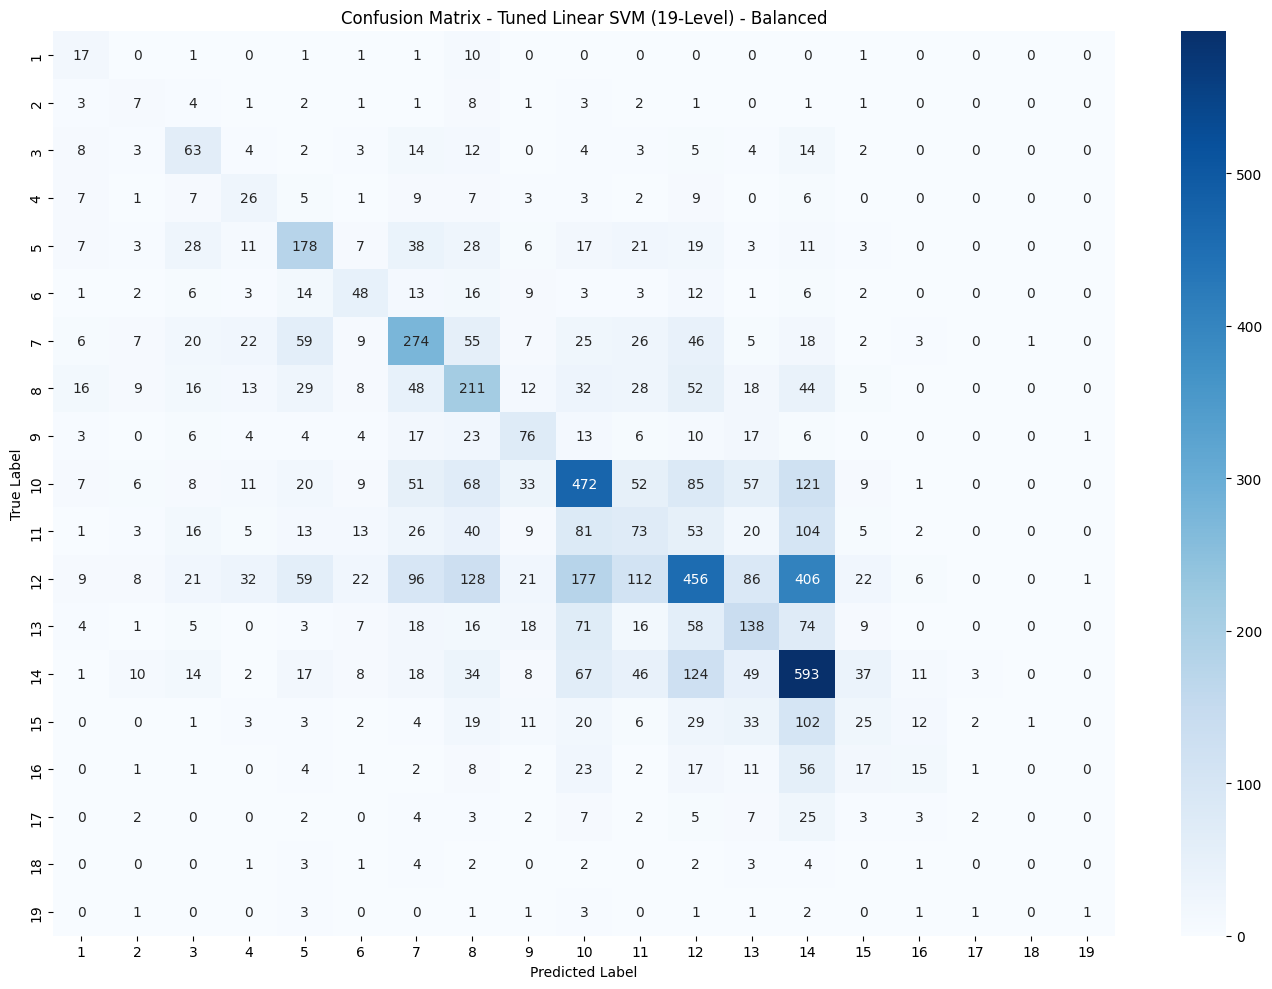

In [ ]:
plot_confusion_matrix(
    svm_y_test_19,
    svm_tuned_19_balanced_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Tuned Linear SVM (19-Level) - Balanced"
)

###**SVM Tuned Findings (19-Level)**
* **class_weight: Balanced**

..

##**SVM Tuned Model (19-Level)**
* **class_weight: None**

In [ ]:
# Create tuned Linear SVM using the best C and loss value without class balancing

svm_tuned_19_none = LinearSVC(
    C=1,
    loss="squared_hinge",
    class_weight=None,
    random_state=42
)

# Train the tuned model
svm_tuned_19_none.fit(
    svm_X_train_tfidf,
    svm_y_train_19
)

# Generate predictions
svm_tuned_19_none_test_pred = svm_tuned_19_none.predict(svm_X_test_tfidf)

In [ ]:
evaluate_svm_model(
    svm_y_test_19,
    svm_tuned_19_none_test_pred,
    "Tuned Linear SVM (19-Level) - None"
)

Tuned Linear SVM (19-Level) - None
Accuracy:                      0.3833
Adjacent Accuracy (±1):        0.5102
Quadratic Weighted Kappa:      0.5492
Macro F1-score:                0.2769
Weighted Precision:            0.3704
Weighted Recall:               0.3833
Mean Absolute Error (MAE):     1.9484
Root Mean Squared Error:       2.9909
R² Score:                      0.1583

Classification Report:

              precision    recall  f1-score   support

           1       0.40      0.53      0.45        32
           2       0.35      0.19      0.25        36
           3       0.42      0.40      0.41       141
           4       0.34      0.26      0.29        86
           5       0.51      0.45      0.48       380
           6       0.42      0.23      0.30       139
           7       0.47      0.44      0.45       585
           8       0.33      0.38      0.35       541
           9       0.45      0.39      0.42       190
          10       0.43      0.49      0.46      1010
   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

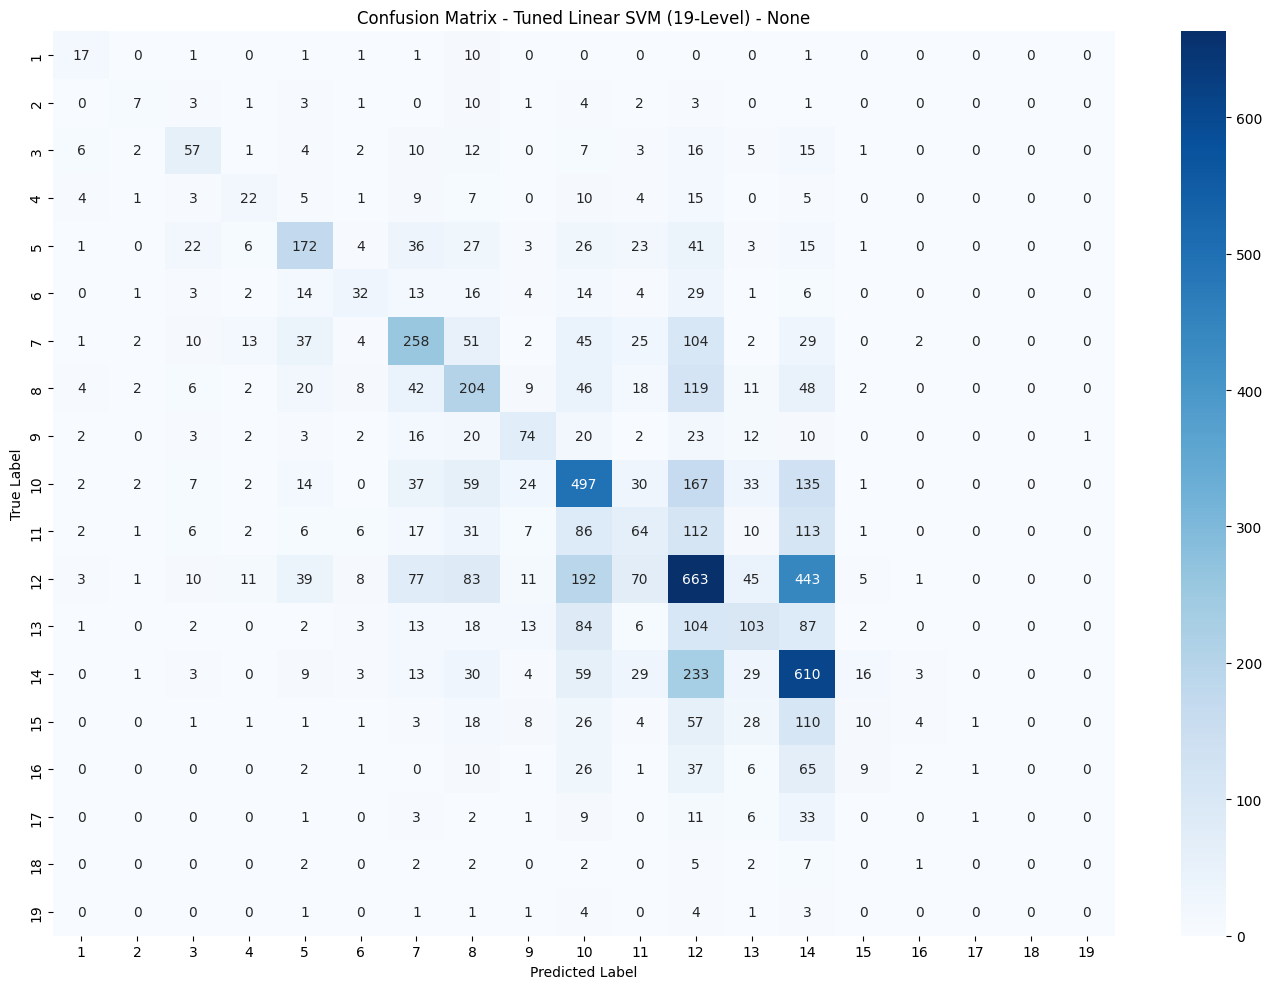

In [ ]:
plot_confusion_matrix(
    svm_y_test_19,
    svm_tuned_19_none_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Tuned Linear SVM (19-Level) - None"
)

###**SVM Tuned Findings (19-Level)**
* **class_weight: None**

..

---

##**SVM Baseline Model (5-Level)**

In [ ]:
# Define target labels for the 5-level classification task

svm_y_train_5 = filtered_train_df["Readability_Level_5"]
svm_y_dev_5 = filtered_dev_df["Readability_Level_5"]
svm_y_test_5 = filtered_test_df["Readability_Level_5"]

In [ ]:
# Import Linear Support Vector Classifier
from sklearn.svm import LinearSVC

# Create the baseline Linear SVM model using default hyperparameters
svm_baseline_5 = LinearSVC(
    random_state=42
)

print(svm_baseline_5.get_params())

{'C': 1.0, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


In [ ]:
# Train the baseline model
svm_baseline_5.fit(
    svm_X_train_tfidf,
    svm_y_train_5
)

LinearSVC(random_state=42)

In [ ]:
# Generate predictions for the test set
svm_baseline_5_test_pred = svm_baseline_5.predict(svm_X_test_tfidf)

In [ ]:
evaluate_svm_model(
    svm_y_test_5,
    svm_baseline_5_test_pred,
    "Baseline SVM (5-Level) - Test Set"
)

Baseline SVM (5-Level) - Test Set
Accuracy:                      0.5215
Adjacent Accuracy (±1):        0.8563
Quadratic Weighted Kappa:      0.5414
Macro F1-score:                0.4326
Weighted Precision:            0.5161
Weighted Recall:               0.5215
Mean Absolute Error (MAE):     0.6502
Root Mean Squared Error:       1.0273
R² Score:                      0.1281

Classification Report:

              precision    recall  f1-score   support

           1       0.63      0.61      0.62      1399
           2       0.53      0.59      0.56      2205
           3       0.49      0.42      0.45      2100
           4       0.45      0.58      0.51      1315
           5       0.30      0.01      0.02       267

    accuracy                           0.52      7286
   macro avg       0.48      0.44      0.43      7286
weighted avg       0.52      0.52      0.51      7286



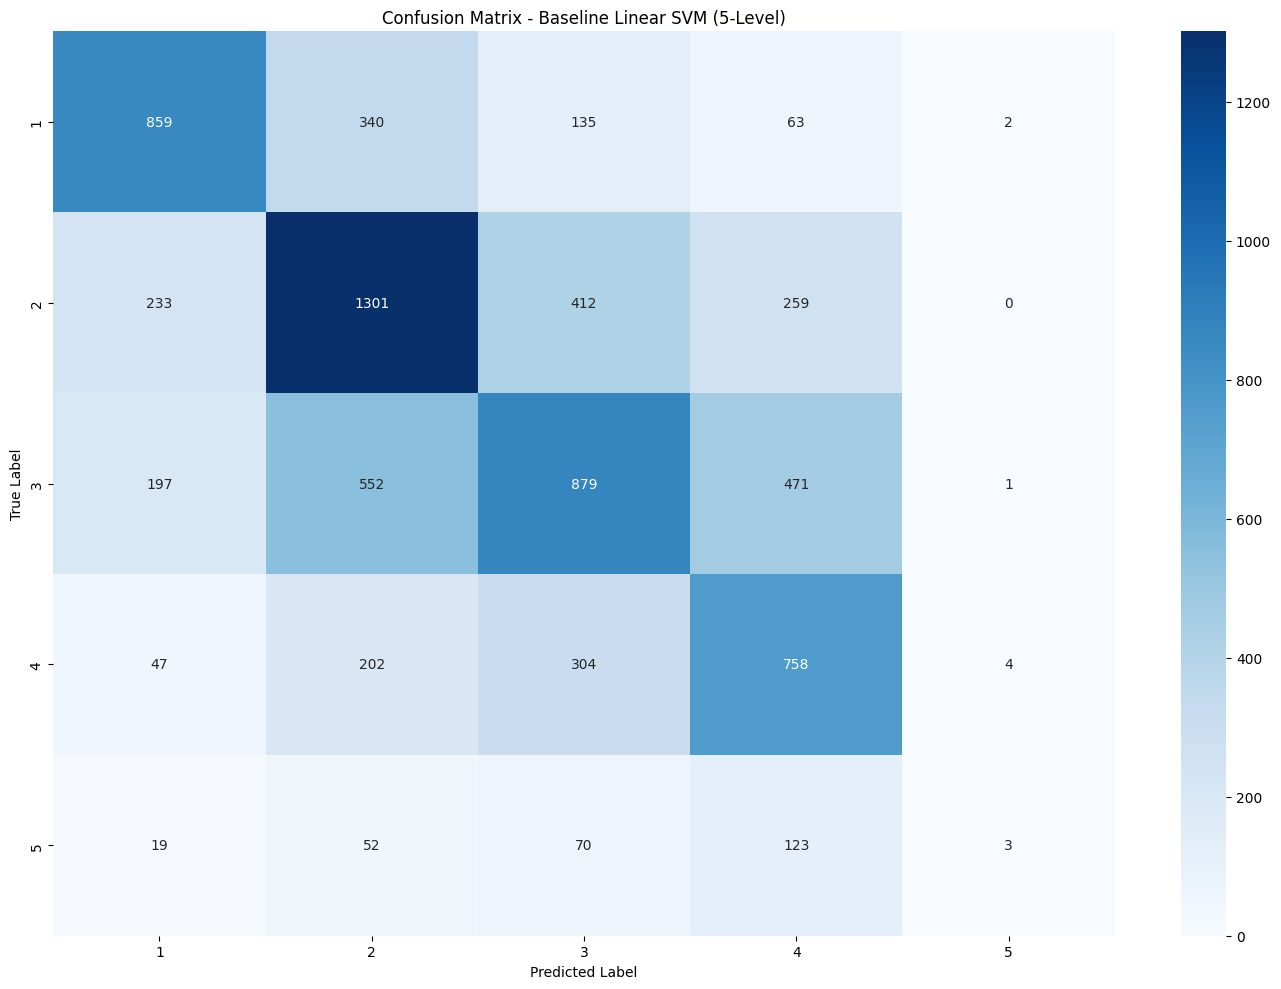

In [ ]:
plot_confusion_matrix(
    svm_y_test_5,
    svm_baseline_5_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Baseline Linear SVM (5-Level)"
)

###**SVM Baseline Findings (5-Level)**
..

##**SVM Hyperparameter Tuning Using GridSearchCV (5-Level)**


**Hyperparameter Search Space Justification**

The hyperparameter search space was selected based on recommendations from previous SVM and text classification literature rather than arbitrary choices.

The regularization parameter **C** and **loss** function were tuned because they directly influence the learning behavior and classification performance of a Linear Support Vector Machine (LinearSVC).

The search space was defined as follows:

- C = [0.01, 0.1, 1, 10, 100]
- Loss = [hinge, squared_hinge]

For the regularization parameter C, exponentially spaced values were selected to cover multiple orders of magnitude, ranging from strong to weak regularization, while maintaining computational efficiency. This follows the general recommendation of Hsu et al. (2016) to search across exponentially spaced values for SVM hyperparameters [1].

For the loss function, both hinge and squared_hinge were included because they are the two loss functions supported by LinearSVC. The hinge loss represents the standard SVM loss, while squared_hinge uses the squared hinge loss, providing an alternative formulation for penalizing classification errors. Including both allows the GridSearchCV procedure to empirically determine which loss function performs better for the given dataset.

The same search space was used for both the 19-level and 5-level readability classification tasks to ensure a fair comparison between the two experimental settings.

Although the candidate values remained identical, the optimal combination of hyperparameters was selected independently for each task using the predefined development set.

**References**


[1] Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2016). A Practical Guide to Support Vector Classification.

In [ ]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.svm import LinearSVC
from scipy.sparse import vstack
import numpy as np

# Define target labels for the 5-level classification task
svm_y_train_5 = filtered_train_df["Readability_Level_5"]
svm_y_dev_5 = filtered_dev_df["Readability_Level_5"]
svm_y_test_5 = filtered_test_df["Readability_Level_5"]

# Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "loss": ["hinge", "squared_hinge"]
}

# Combine Training and Development features
X_train_dev = vstack([
    svm_X_train_tfidf,
    svm_X_dev_tfidf
])

# Combine Training and Development labels
y_train_dev = np.concatenate([
    svm_y_train_5,
    svm_y_dev_5
])

# Define the fixed split
# -1 = Training set
#  0 = Development set
test_fold = np.concatenate([
    np.full(len(svm_y_train_5), -1),
    np.zeros(len(svm_y_dev_5))
])

predefined_split = PredefinedSplit(test_fold=test_fold)

# Grid Search
svm_grid_5 = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=predefined_split,
    n_jobs=-1,
    verbose=2
)

# Hyperparameter tuning
svm_grid_5.fit(
    X_train_dev,
    y_train_dev
)

# Print the best parameters and development accuracy
print("Best Parameters:", svm_grid_5.best_params_)
print(f"Best Development Accuracy: {svm_grid_5.best_score_:.4f}")

Fitting 1 folds for each of 10 candidates, totalling 10 fits
Best Parameters: {'C': 1, 'loss': 'hinge'}
Best Development Accuracy: 0.5454


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


##**SVM Tuned Model (5-Level)**
* **class_weight: Balanced**

In [41]:
# Create tuned Linear SVM using the best C and loss value with balanced class weights

svm_tuned_5_balanced = LinearSVC(
    C=1,
    loss="hinge",
    class_weight="balanced",
    random_state=42
)

# Train the tuned model
svm_tuned_5_balanced.fit(
    svm_X_train_tfidf,
    svm_y_train_5
)

# Generate predictions
svm_tuned_5_balanced_test_pred = svm_tuned_5_balanced.predict(svm_X_test_tfidf)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [42]:
evaluate_svm_model(
    svm_y_test_5,
    svm_tuned_5_balanced_test_pred,
    "Tuned Linear SVM (5-Level) - Balanced"
)

Tuned Linear SVM (5-Level) - Balanced
Accuracy:                      0.5117
Adjacent Accuracy (±1):        0.8295
Quadratic Weighted Kappa:      0.5428
Macro F1-score:                0.4445
Weighted Precision:            0.5199
Weighted Recall:               0.5117
Mean Absolute Error (MAE):     0.6943
Root Mean Squared Error:       1.0883
R² Score:                      0.0215

Classification Report:

              precision    recall  f1-score   support

           1       0.59      0.71      0.64      1399
           2       0.58      0.50      0.54      2205
           3       0.52      0.34      0.41      2100
           4       0.40      0.67      0.50      1315
           5       0.28      0.08      0.13       267

    accuracy                           0.51      7286
   macro avg       0.47      0.46      0.44      7286
weighted avg       0.52      0.51      0.50      7286



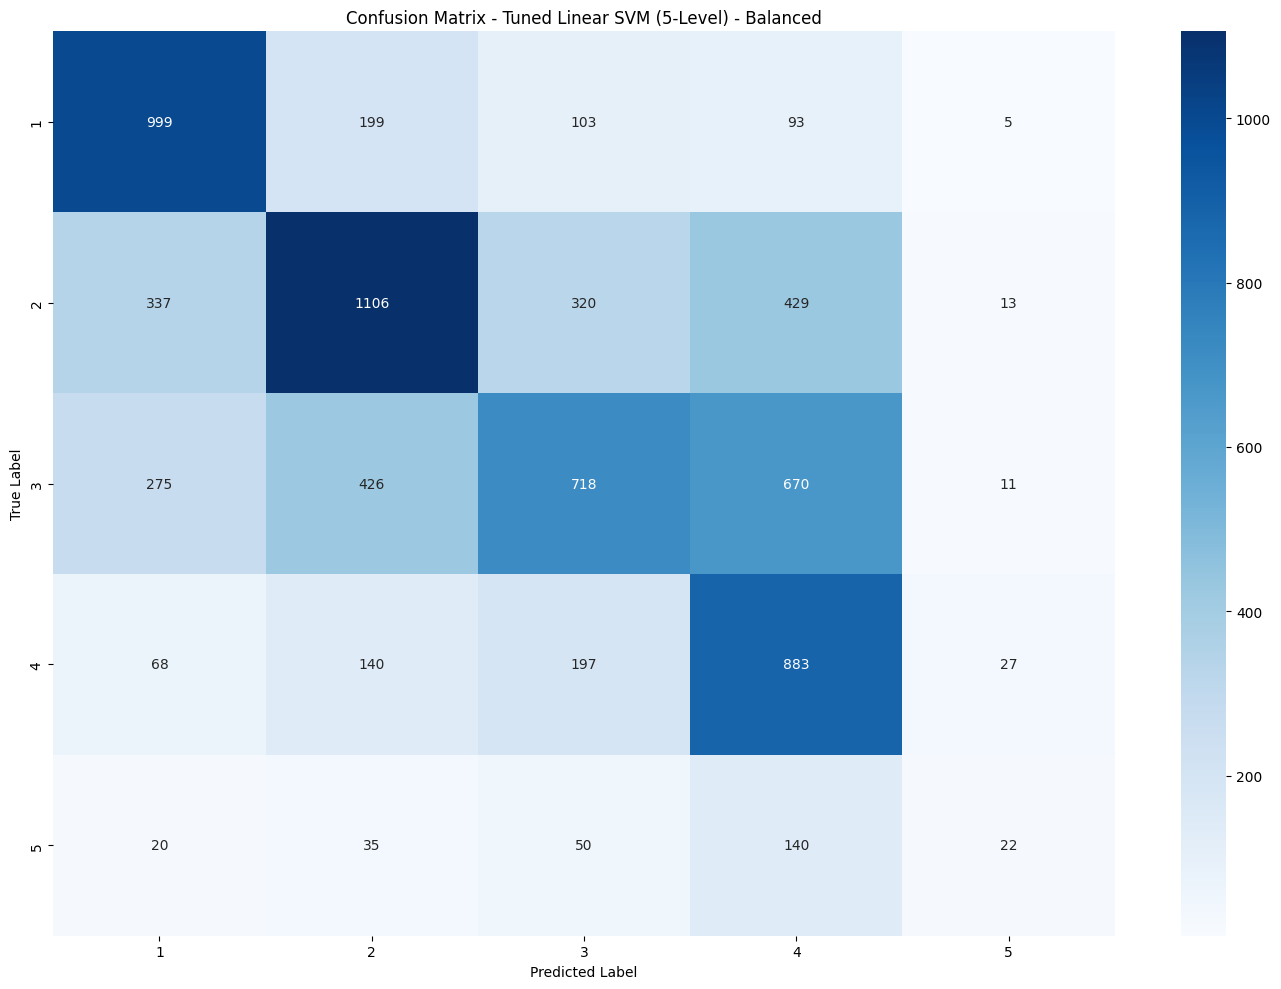

In [43]:
plot_confusion_matrix(
    svm_y_test_5,
    svm_tuned_5_balanced_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Tuned Linear SVM (5-Level) - Balanced"
)

###**SVM Tuned Findings (5-Level)**
* **class_weight: Balanced**

..

##**SVM Tuned Model (5-Level)**
* **class_weight: None**

In [44]:
# Create tuned Linear SVM using the best C and loss value without class balancing

svm_tuned_5_none = LinearSVC(
    C=1,
    loss="hinge",
    class_weight=None,
    random_state=42
)

# Train the tuned model
svm_tuned_5_none.fit(
    svm_X_train_tfidf,
    svm_y_train_5
)

# Generate predictions
svm_tuned_5_none_dev_pred = svm_tuned_5_none.predict(svm_X_dev_tfidf)
svm_tuned_5_none_test_pred = svm_tuned_5_none.predict(svm_X_test_tfidf)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [45]:
evaluate_svm_model(
    svm_y_test_5,
    svm_tuned_5_none_test_pred,
    "Tuned Linear SVM (5-Level) - None"
)

Tuned Linear SVM (5-Level) - None
Accuracy:                      0.5200
Adjacent Accuracy (±1):        0.8471
Quadratic Weighted Kappa:      0.5285
Macro F1-score:                0.4296
Weighted Precision:            0.5178
Weighted Recall:               0.5200
Mean Absolute Error (MAE):     0.6651
Root Mean Squared Error:       1.0519
R² Score:                      0.0858

Classification Report:

              precision    recall  f1-score   support

           1       0.62      0.62      0.62      1399
           2       0.53      0.60      0.57      2205
           3       0.51      0.39      0.44      2100
           4       0.44      0.59      0.50      1315
           5       0.33      0.01      0.02       267

    accuracy                           0.52      7286
   macro avg       0.49      0.44      0.43      7286
weighted avg       0.52      0.52      0.51      7286



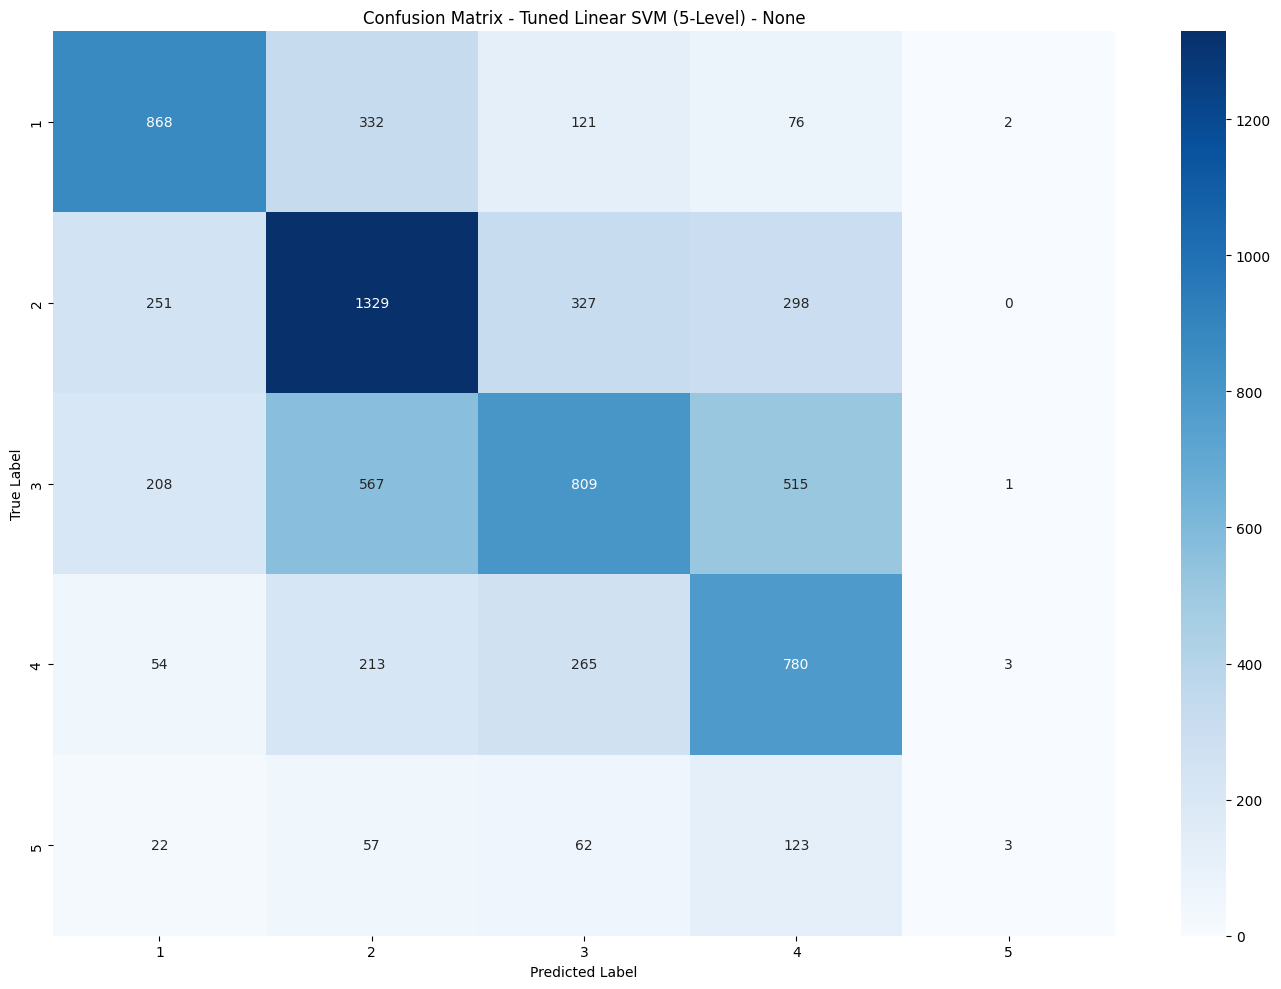

In [46]:
plot_confusion_matrix(
    svm_y_test_5,
    svm_tuned_5_none_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Tuned Linear SVM (5-Level) - None"
)

###**SVM Tuned Findings (5-Level)**
* **class_weight: None**

..

## Step 1: Merge Readability Classes 4 and 5

The original `Readability_Level_5` contains five readability classes.

To reduce the class imbalance, Classes 4 and 5 will be merged into a single class. All samples originally labeled as Class 5 will be relabeled as Class 4.

As a result, the dataset will contain four readability classes: 1, 2, 3, and 4.

The original Class 5 label will no longer exist in the dataset.

In [47]:
# Create a copy of the dataset
readability_4class_df = filtered_full_df.copy()

# Merge Class 5 into Class 4
readability_4class_df["Readability_Level_5"] = (
    readability_4class_df["Readability_Level_5"].replace(5, 4)
)

# Rename the label column to reflect the new four-class task
readability_4class_df = readability_4class_df.rename(
    columns={"Readability_Level_5": "Readability_Level_4"}
)

# Check the new class distribution
print("=== Readability Level 4-Class Distribution ===")
display(
    readability_4class_df["Readability_Level_4"]
    .value_counts()
    .sort_index()
)

=== Readability Level 4-Class Distribution ===


,count
Readability_Level_4,
1,13474
2,22383
3,18510
4,15074


## Step 2: Stratified Split for the Four-Class Dataset

The four-class dataset will be divided into 80% training, 10% validation, and 10% testing sets using stratified sampling.

Stratification ensures that the proportion of each readability class is preserved across the three sets.

The split is performed after merging Classes 4 and 5 so that the final class distribution is properly represented in the training, validation, and test sets.

In [48]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
train_4, temp_4 = train_test_split(
    readability_4class_df,
    test_size=0.20,
    stratify=readability_4class_df["Readability_Level_4"],
    random_state=42
)

# Second split: 10% validation, 10% test
val_4, test_4 = train_test_split(
    temp_4,
    test_size=0.50,
    stratify=temp_4["Readability_Level_4"],
    random_state=42
)

# Display the size of each split
print("=== Four-Class Dataset Split ===")
print(f"Train: {len(train_4)}")
print(f"Validation: {len(val_4)}")
print(f"Test: {len(test_4)}")

=== Four-Class Dataset Split ===
Train: 55552
Validation: 6944
Test: 6945


## Step 3: Verify the Stratified Split

The class distribution will be compared across the training, validation, and test sets to verify that stratified splitting preserved the proportions of all four readability classes.

In [49]:
# Calculate class distribution for each split
distribution_4class = pd.DataFrame({
    "Train": train_4["Readability_Level_4"].value_counts(normalize=True) * 100,
    "Validation": val_4["Readability_Level_4"].value_counts(normalize=True) * 100,
    "Test": test_4["Readability_Level_4"].value_counts(normalize=True) * 100
}).sort_index()

# Round percentages
distribution_4class = distribution_4class.round(2)

print("=== Readability Level 4-Class Distribution ===")
display(distribution_4class)

=== Readability Level 4-Class Distribution ===


,Train,Validation,Test
Readability_Level_4,,,
1,19.40,19.41,19.40
2,32.23,32.23,32.24
3,26.66,26.66,26.65
4,21.71,21.70,21.71


## Step 4: Analyze the Training Class Distribution

The number and percentage of samples in each class will be analyzed in the training set.

This step is used to evaluate the remaining class imbalance after merging Classes 4 and 5 and to determine whether additional balancing techniques are necessary.

In [50]:
# Analyze the training class distribution
train_4class_distribution = (
    train_4["Readability_Level_4"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

train_4class_distribution["Percentage"] = (
    train_4class_distribution["Count"] / len(train_4) * 100
).round(2)

print("=== Readability Level 4-Class Training Distribution ===")
display(train_4class_distribution)

=== Readability Level 4-Class Training Distribution ===


,Count,Percentage
Readability_Level_4,,
1,10779,19.40
2,17906,32.23
3,14808,26.66
4,12059,21.71


## Step 5: Verify Final Class Distribution

The final class distribution is verified across the training, validation, and test sets.

The purpose of this step is to ensure that the four readability classes remain consistently represented across all datasets after merging Classes 4 and 5 and applying stratified splitting.

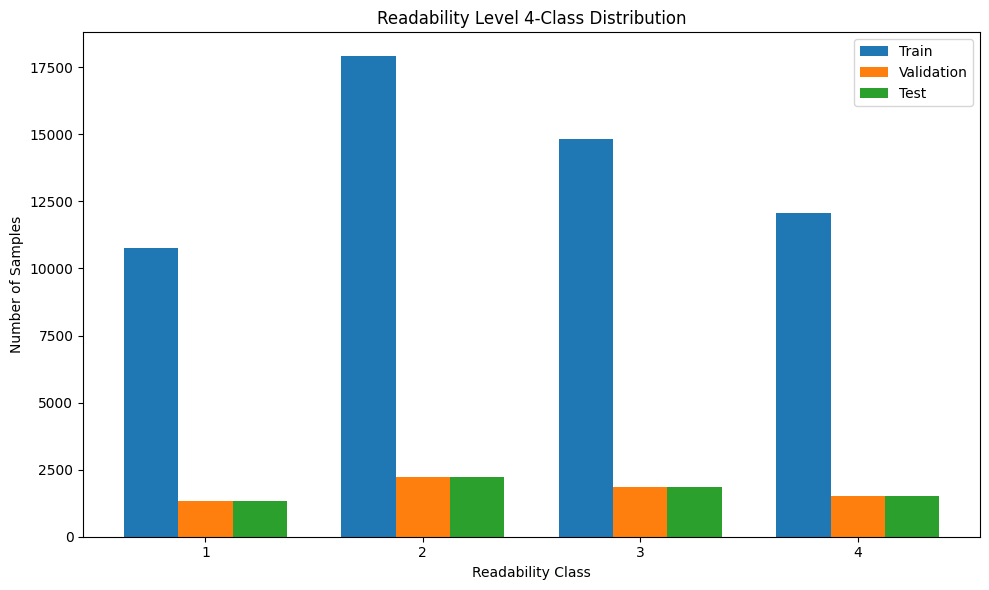

In [51]:
import matplotlib.pyplot as plt

# Class counts across all splits
classes = [1, 2, 3, 4]

train_counts = train_4["Readability_Level_4"].value_counts().sort_index()
val_counts = val_4["Readability_Level_4"].value_counts().sort_index()
test_counts = test_4["Readability_Level_4"].value_counts().sort_index()

x = range(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width for i in x],
    train_counts.values,
    width=width,
    label="Train"
)

plt.bar(
    x,
    val_counts.values,
    width=width,
    label="Validation"
)

plt.bar(
    [i + width for i in x],
    test_counts.values,
    width=width,
    label="Test"
)

plt.xlabel("Readability Class")
plt.ylabel("Number of Samples")
plt.title("Readability Level 4-Class Distribution")
plt.xticks(x, classes)
plt.legend()
plt.tight_layout()
plt.show()

##**SVM Baseline Model (4-Level)**

In [57]:
# New 4-class classification task

svm_X_train_4 = train_4["Word"]
svm_X_dev_4 = val_4["Word"]
svm_X_test_4 = test_4["Word"]

svm_vectorizer_4 = TfidfVectorizer(
    ngram_range=(1, 2)
)

svm_X_train_tfidf_4 = svm_vectorizer_4.fit_transform(svm_X_train_4)
svm_X_dev_tfidf_4 = svm_vectorizer_4.transform(svm_X_dev_4)
svm_X_test_tfidf_4 = svm_vectorizer_4.transform(svm_X_test_4)

In [58]:
# Define target labels for the 4-level classification task

svm_y_train_4 = train_4["Readability_Level_4"]
svm_y_dev_4 = val_4["Readability_Level_4"]
svm_y_test_4 = test_4["Readability_Level_4"]

In [59]:
print("X Train:", svm_X_train_tfidf_4.shape)
print("y Train:", svm_y_train_4.shape)

print("X Validation:", svm_X_dev_tfidf_4.shape)
print("y Validation:", svm_y_dev_4.shape)

print("X Test:", svm_X_test_tfidf_4.shape)
print("y Test:", svm_y_test_4.shape)

X Train: (55552, 525562)
y Train: (55552,)
X Validation: (6944, 525562)
y Validation: (6944,)
X Test: (6945, 525562)
y Test: (6945,)


In [60]:
# Import Linear Support Vector Classifier
from sklearn.svm import LinearSVC

# Create the baseline Linear SVM model using default hyperparameters
svm_baseline_4 = LinearSVC(
    random_state=42
)

print(svm_baseline_4.get_params())

{'C': 1.0, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


In [63]:
# Train the baseline model
svm_baseline_4.fit(
    svm_X_train_tfidf_4,
    svm_y_train_4
)

LinearSVC(random_state=42)

In [65]:
# Generate predictions for the test set
svm_baseline_4_test_pred = svm_baseline_4.predict(
    svm_X_test_tfidf_4
)

In [66]:
evaluate_svm_model(
    svm_y_test_4,
    svm_baseline_4_test_pred,
    "Baseline SVM (4-Level) - Test Set"
)

Baseline SVM (4-Level) - Test Set
Accuracy:                      0.5935
Adjacent Accuracy (±1):        0.8847
Quadratic Weighted Kappa:      0.6324
Macro F1-score:                0.5998
Weighted Precision:            0.5920
Weighted Recall:               0.5935
Mean Absolute Error (MAE):     0.5336
Root Mean Squared Error:       0.9008
R² Score:                      0.2431

Classification Report:

              precision    recall  f1-score   support

           1       0.69      0.70      0.70      1347
           2       0.61      0.59      0.60      2239
           3       0.51      0.47      0.49      1851
           4       0.58      0.66      0.62      1508

    accuracy                           0.59      6945
   macro avg       0.60      0.60      0.60      6945
weighted avg       0.59      0.59      0.59      6945



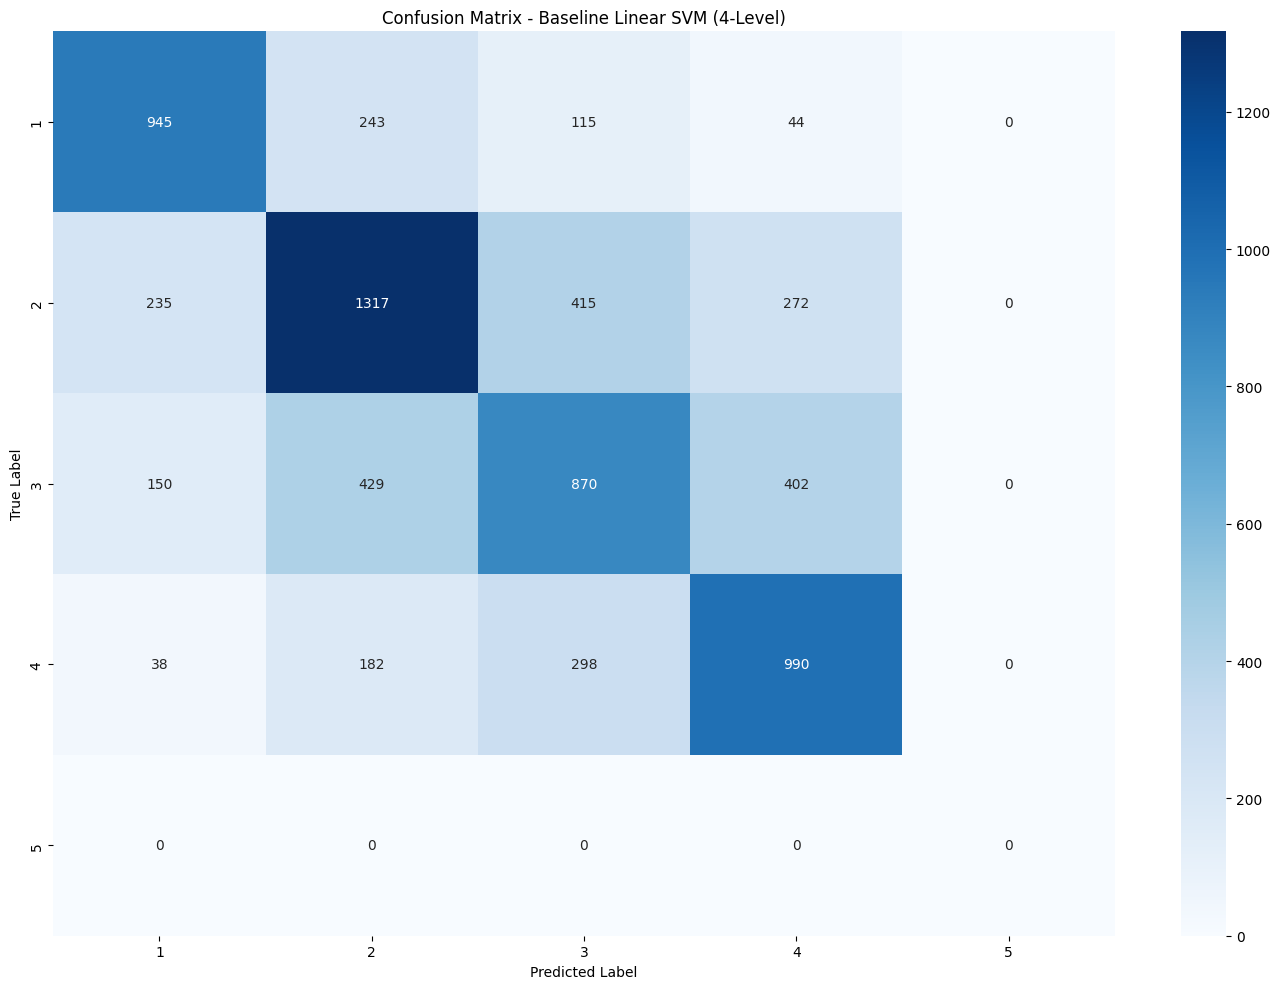

In [67]:
plot_confusion_matrix(
    svm_y_test_4,
    svm_baseline_4_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Baseline Linear SVM (4-Level)"
)

###**SVM Baseline Findings (4-Level)**
..

##**SVM Hyperparameter Tuning Using GridSearchCV (4-Level)**


**Hyperparameter Search Space Justification**

The hyperparameter search space was selected based on recommendations from previous SVM and text classification literature rather than arbitrary choices.

The regularization parameter **C** and **loss** function were tuned because they directly influence the learning behavior and classification performance of a Linear Support Vector Machine (LinearSVC).

The search space was defined as follows:

- C = [0.01, 0.1, 1, 10, 100]
- Loss = [hinge, squared_hinge]

For the regularization parameter C, exponentially spaced values were selected to cover multiple orders of magnitude, ranging from strong to weak regularization, while maintaining computational efficiency. This follows the general recommendation of Hsu et al. (2016) to search across exponentially spaced values for SVM hyperparameters [1].

For the loss function, both hinge and squared_hinge were included because they are the two loss functions supported by LinearSVC. The hinge loss represents the standard SVM loss, while squared_hinge uses the squared hinge loss, providing an alternative formulation for penalizing classification errors. Including both allows the GridSearchCV procedure to empirically determine which loss function performs better for the given dataset.

The same search space was used for both the 19-level and 5-level readability classification tasks to ensure a fair comparison between the two experimental settings.

Although the candidate values remained identical, the optimal combination of hyperparameters was selected independently for each task using the predefined development set.

**References**


[1] Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2016). A Practical Guide to Support Vector Classification.

In [68]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.svm import LinearSVC
from scipy.sparse import vstack
import numpy as np

# Define target labels for the 4-level classification task
svm_y_train_4 = train_4["Readability_Level_4"]
svm_y_dev_4 = val_4["Readability_Level_4"]
svm_y_test_4 = test_4["Readability_Level_4"]

# Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "loss": ["hinge", "squared_hinge"]
}

# Combine Training and Development features
X_train_dev_4 = vstack([
    svm_X_train_tfidf_4,
    svm_X_dev_tfidf_4
])

# Combine Training and Development labels
y_train_dev_4 = np.concatenate([
    svm_y_train_4,
    svm_y_dev_4
])

# Define the fixed split
# -1 = Training set
#  0 = Development set
test_fold_4 = np.concatenate([
    np.full(len(svm_y_train_4), -1),
    np.zeros(len(svm_y_dev_4))
])

predefined_split_4 = PredefinedSplit(
    test_fold=test_fold_4
)

# Grid Search
svm_grid_4 = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=predefined_split_4,
    n_jobs=-1,
    verbose=2
)

# Hyperparameter tuning
svm_grid_4.fit(
    X_train_dev_4,
    y_train_dev_4
)

# Print the best parameters and development accuracy
print("Best Parameters:", svm_grid_4.best_params_)
print(f"Best Development Accuracy: {svm_grid_4.best_score_:.4f}")

Fitting 1 folds for each of 10 candidates, totalling 10 fits
Best Parameters: {'C': 1, 'loss': 'squared_hinge'}
Best Development Accuracy: 0.5955


##**SVM Tuned Model (4-Level)**
* **class_weight: Balanced**

In [70]:
# Create tuned Linear SVM using the best C and loss value with balanced class weights

svm_tuned_4_balanced = LinearSVC(
    C=1,
    loss="squared_hinge",
    class_weight="balanced",
    random_state=42
)

# Train the tuned model
svm_tuned_4_balanced.fit(
    svm_X_train_tfidf_4,
    svm_y_train_4
)

# Generate predictions
svm_tuned_4_balanced_test_pred = svm_tuned_4_balanced.predict(
    svm_X_test_tfidf_4
)

In [71]:
evaluate_svm_model(
    svm_y_test_4,
    svm_tuned_4_balanced_test_pred,
    "Tuned Linear SVM (4-Level) - Balanced"
)

Tuned Linear SVM (4-Level) - Balanced
Accuracy:                      0.5927
Adjacent Accuracy (±1):        0.8837
Quadratic Weighted Kappa:      0.6377
Macro F1-score:                0.5988
Weighted Precision:            0.5911
Weighted Recall:               0.5927
Mean Absolute Error (MAE):     0.5359
Root Mean Squared Error:       0.9042
R² Score:                      0.2374

Classification Report:

              precision    recall  f1-score   support

           1       0.68      0.73      0.70      1347
           2       0.62      0.56      0.59      2239
           3       0.51      0.46      0.49      1851
           4       0.57      0.68      0.62      1508

    accuracy                           0.59      6945
   macro avg       0.59      0.61      0.60      6945
weighted avg       0.59      0.59      0.59      6945



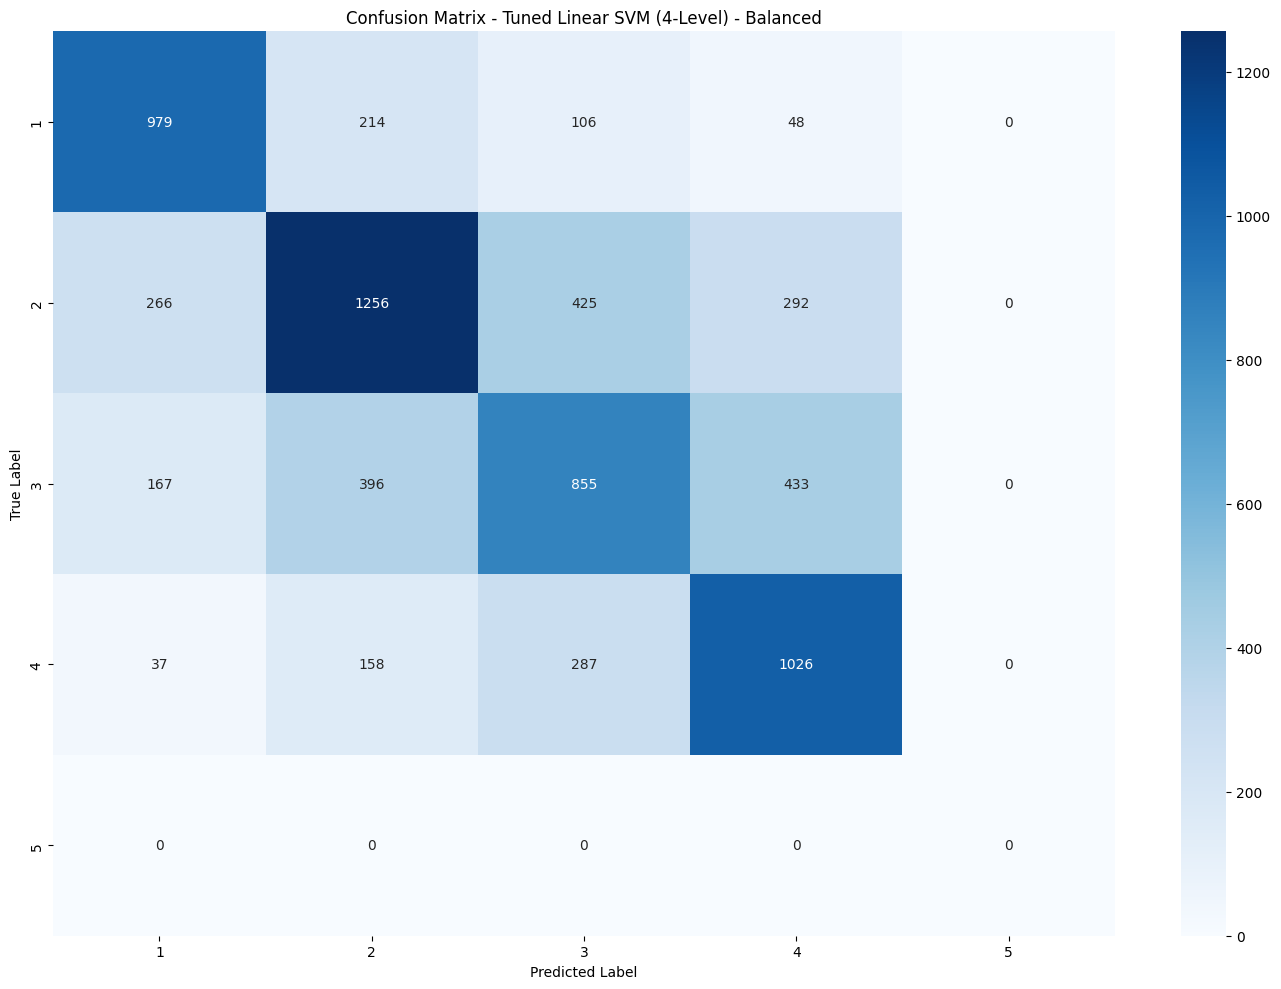

In [72]:
plot_confusion_matrix(
    svm_y_test_4,
    svm_tuned_4_balanced_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Tuned Linear SVM (4-Level) - Balanced"
)

###**SVM Tuned Findings (4-Level)**
* **class_weight: Balanced**

..

##**SVM Tuned Model (4-Level)**
* **class_weight: None**

In [73]:
# Create tuned Linear SVM using the best C and loss value without class balancing

svm_tuned_4_none = LinearSVC(
    C=1,
    loss="squared_hinge",
    class_weight=None,
    random_state=42
)

# Train the tuned model
svm_tuned_4_none.fit(
    svm_X_train_tfidf_4,
    svm_y_train_4
)

# Generate predictions
svm_tuned_4_none_dev_pred = svm_tuned_4_none.predict(
    svm_X_dev_tfidf_4
)

svm_tuned_4_none_test_pred = svm_tuned_4_none.predict(
    svm_X_test_tfidf_4
)

In [74]:
evaluate_svm_model(
    svm_y_test_4,
    svm_tuned_4_none_test_pred,
    "Tuned Linear SVM (4-Level) - None"
)

Tuned Linear SVM (4-Level) - None
Accuracy:                      0.5935
Adjacent Accuracy (±1):        0.8847
Quadratic Weighted Kappa:      0.6324
Macro F1-score:                0.5998
Weighted Precision:            0.5920
Weighted Recall:               0.5935
Mean Absolute Error (MAE):     0.5336
Root Mean Squared Error:       0.9008
R² Score:                      0.2431

Classification Report:

              precision    recall  f1-score   support

           1       0.69      0.70      0.70      1347
           2       0.61      0.59      0.60      2239
           3       0.51      0.47      0.49      1851
           4       0.58      0.66      0.62      1508

    accuracy                           0.59      6945
   macro avg       0.60      0.60      0.60      6945
weighted avg       0.59      0.59      0.59      6945



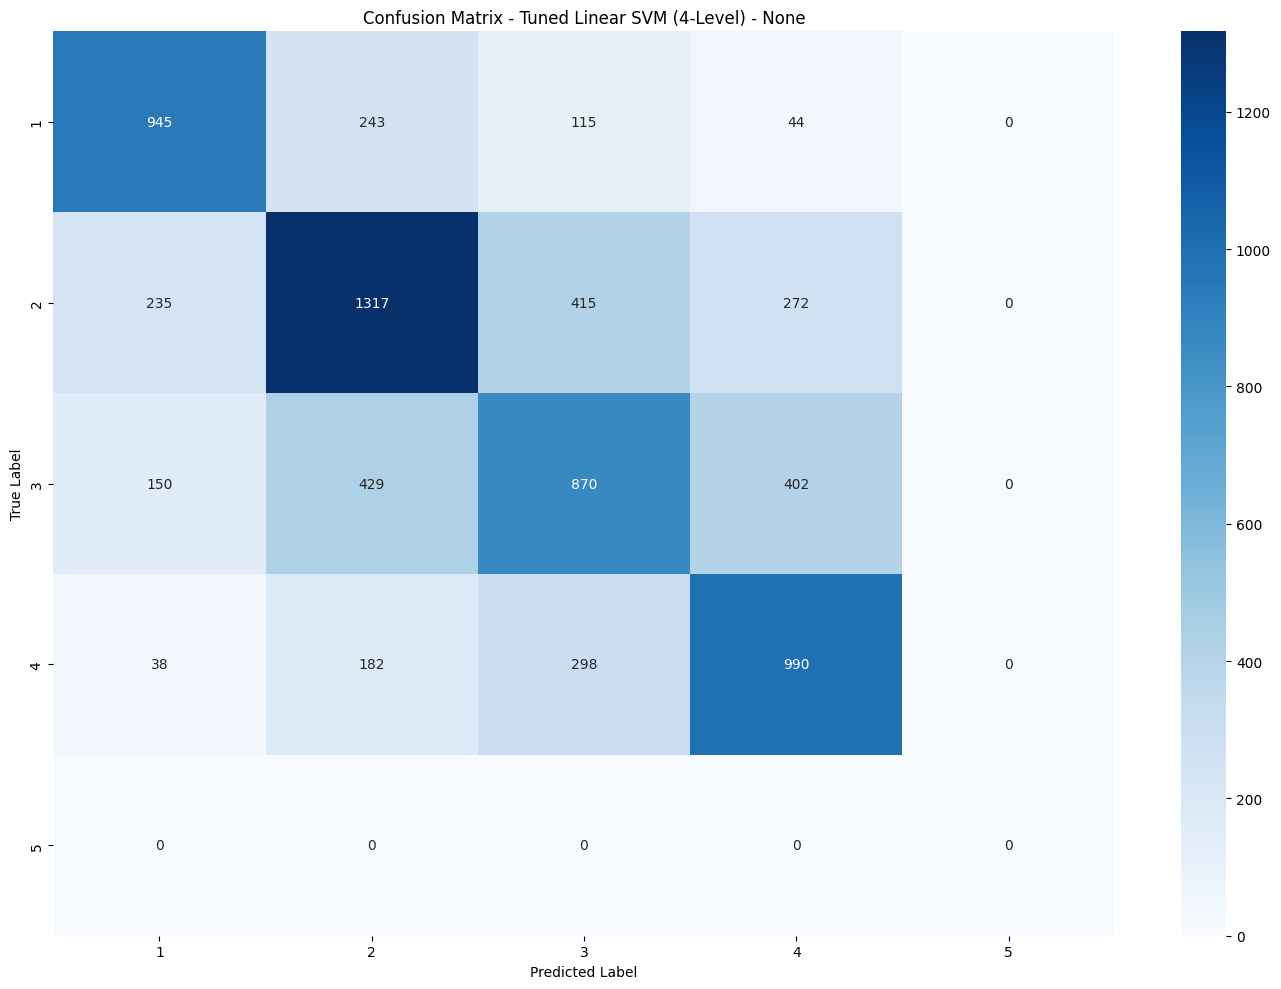

In [75]:
plot_confusion_matrix(
    svm_y_test_4,
    svm_tuned_4_none_test_pred,
    labels=list(range(1,6)),
    title="Confusion Matrix - Tuned Linear SVM (4-Level) - None"
)

###**SVM Tuned Findings (4-Level)**
* **class_weight: None**

..

#**Comparison between 19 & 5 Level Results**


### SVM Model (19-Level)

| Model | Accuracy | Adjacent Accuracy (±1) | Quadratic Weighted Kappa | Macro F1-score | Weighted Precision | Weighted Recall | MAE | RMSE | R² Score |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **SVM Baseline Model** | **0.3833** | **0.5102** | **0.5492** | **0.2769** | 0.3704 | **0.3833** | **1.9484** | **2.9909** | **0.1583** |
| **SVM Tuned Model (Balanced)** | 0.3671 | 0.5045 | 0.5308 | 0.2686 | **0.3720** | 0.3671 | 2.1264 | 3.2855 | -0.0157 |
| **SVM Tuned Model (None)** | **0.3833** | **0.5102** | **0.5492** | **0.2769** | 0.3704 | **0.3833** | **1.9484** | **2.9909** | **0.1583** |

<br>

### SVM Model (5-Level)

| Model | Accuracy | Adjacent Accuracy (±1) | Quadratic Weighted Kappa | Macro F1-score | Weighted Precision | Weighted Recall | MAE | RMSE | R² Score |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **SVM Baseline Model** | **0.5215** | **0.8563** | 0.5414 | 0.4326 | 0.5161 | **0.5215** | **0.6502** | **1.0273** | **0.1281** |
| **SVM Tuned Model (Balanced)** | 0.5117 | 0.8295 | **0.5428** | **0.4445** | **0.5199** | 0.5117 | 0.6943 | 1.0883 | 0.0215 |
| **SVM Tuned Model (None)** | 0.5200 | 0.8471 | 0.5285 | 0.4296 | 0.5178 | 0.5200 | 0.6651 | 1.0519 | 0.0858 |

<br>

### SVM Model (4-Level)

| Model | Accuracy | Adjacent Accuracy (±1) | Quadratic Weighted Kappa | Macro F1-score | Weighted Precision | Weighted Recall | MAE | RMSE | R² Score |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **SVM Baseline Model** | **0.5935** | **0.8847** | 0.6324 | **0.5998** | **0.5920** | **0.5935** | **0.5336** | **0.9008** | **0.2431** |
| **SVM Tuned Model (Balanced)** | 0.5927 | 0.8837 | **0.6377** | 0.5988 | 0.5911 | 0.5927 | 0.5359 | 0.9042 | 0.2374 |
| **SVM Tuned Model (None)** | **0.5935** | **0.8847** | 0.6324 | **0.5998** | **0.5920** | **0.5935** | **0.5336** | **0.9008** | **0.2431** |

**SVM Performance Comparison Level 19 (Baseline vs Tuned vs Paper Results)**

| Model | Acc19 | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|
| Paper SVM (Word) | 36.2% | 47.9% | 2.03 | 53.4% |
| Our SVM (Baseline) | 34.15% | 49.00% | 2.23 | 53.15% |
| Our SVM (Tuned) | 36.66% | 50.82% | 1.97 | 54.77% |

**SVM Performance Comparison Level 5 (Baseline vs Tuned)**

| Model | Acc5 | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|
| Our SVM (Baseline - 5 Level) | 51.88% | 85.75% | 0.6521 | 54.16% |
| Our SVM (Tuned - 5 Level) | 51.81% | 83.16% | 0.6938 | 54.91% |

**SVM Performance Comparison (Paper vs Our Model - 19-Level & 5-Level)**

| Model | Level | Acc | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|---|
| Paper SVM (Word) | 19 | 36.2% | 47.9% | 2.03 | 53.4% |
| Our SVM (Baseline) | 19 | 34.15% | 49.00% | 2.23 | 53.15% |
| Our SVM (Tuned) | 19 | **36.66%** | **50.82%** | **1.97** | **54.77%** |
| Our SVM (Baseline) | 5 | **51.88%** | **85.75%** | **0.65** | 54.16% |
| Our SVM (Tuned) | 5 | 51.81% | 83.16% | 0.69 | **54.91%** |

Tasks:-

1. GitHub files seperation & Fix Structure
2. parametres search (Fix GridSearch, Fix scoring accuracy, Fix cv ?, Fix n_jobs ?, Fix verbose ?) + check loops
3. Diff Tunning for level 19(balanced, none) & 5(balansed, none)
4. Aug filtered level 5 dataset using (BERT-based Aug)
5. Document in overleaf (why this model, models parameters justification, model results + matrix, Aug methods and pros & cons justify your options with resources)


Each 6 models and 2 gridsearch

model 19 initial
gridsearch
model 19 tuned (balansed)
modle 19 tunded (none)


model 5 initial
gridsearch
model 5 tuned (balanced)
model 5 tuned (none)